# MIMIC-IV 30-Day Readmission Prediction
## Notebook 4: Evaluation and Explainability

This notebook provides comprehensive evaluation of the XGBoost model including:
1. Calibration analysis - do predicted probabilities match actual readmission rates?
2. SHAP explainability - which features drive predictions globally and individually?
3. Subgroup fairness analysis - does the model perform equally across patient groups?
4. Clinical utility analysis - how useful is this model in practice?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
import xgboost as xgb
import shap

pd.set_option('display.float_format', '{:.4f}'.format)

DATA_DIR = Path('../data')
FIGURES_DIR = Path('../figures')

print("Libraries loaded successfully")

# Check versions
import sklearn
print(f"scikit-learn version: {sklearn.__version__}")
print(f"XGBoost version: {xgb.__version__}")
print(f"SHAP version: {shap.__version__}")

Libraries loaded successfully
scikit-learn version: 1.7.2
XGBoost version: 1.7.6
SHAP version: 0.49.1


In [2]:
print("Loading data and models...")

# Load feature matrix and feature cols
feature_matrix = pd.read_csv(DATA_DIR / 'feature_matrix.csv')
with open(DATA_DIR / 'feature_cols.json', 'r') as f:
    feature_cols = json.load(f)

# Load test predictions from notebook 3
test_predictions = pd.read_csv(DATA_DIR / 'test_predictions.csv')

# Load models
with open(DATA_DIR / 'xgb_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

with open(DATA_DIR / 'lr_model.pkl', 'rb') as f:
    lr_model = pickle.load(f)

with open(DATA_DIR / 'scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

print(f"Feature matrix: {feature_matrix.shape}")
print(f"Test predictions: {test_predictions.shape}")
print(f"Features: {len(feature_cols)}")

# Extract arrays
y_test = test_predictions['y_true'].values
xgb_probs = test_predictions['xgb_prob'].values
lr_probs = test_predictions['lr_prob'].values

# Get test feature matrix
test_mask = feature_matrix['hadm_id'].isin(test_predictions['hadm_id'])
test_df = feature_matrix[test_mask].copy()
X_test = test_df[feature_cols].values

print(f"\nTest set: {len(y_test):,} admissions")
print(f"Readmission rate: {y_test.mean():.1%}")

Loading data and models...
Feature matrix: (534152, 47)
Test predictions: (106831, 4)
Features: 45

Test set: 106,831 admissions
Readmission rate: 18.1%


=== CALIBRATION ANALYSIS ===

Calibration measures whether predicted probabilities match actual outcomes.
A perfectly calibrated model predicts 30% probability for patients where
exactly 30% actually get readmitted.
This is critical for clinical decision-making - if the model says 40% risk,
clinicians need to trust that number.

Logistic Regression:
  Brier Score: 0.2396 (lower is better)
  AUC-ROC: 0.6317

XGBoost:
  Brier Score: 0.2286 (lower is better)
  AUC-ROC: 0.6699



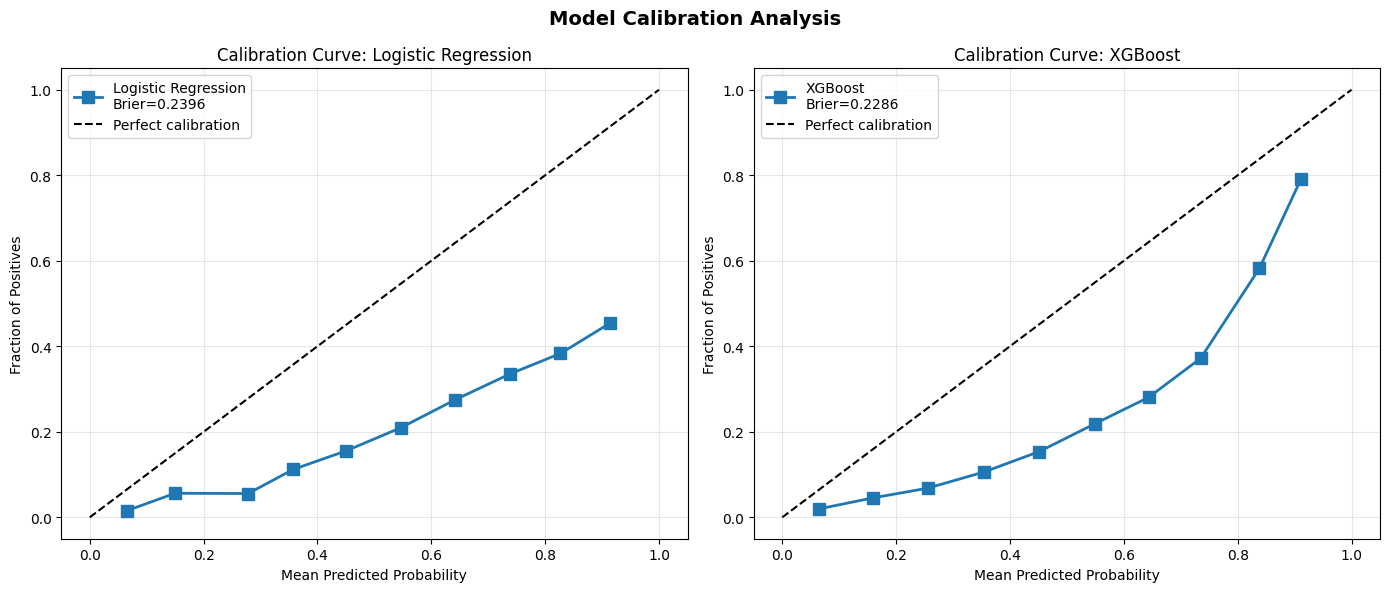

Figure saved


In [3]:
print("=== CALIBRATION ANALYSIS ===")
print("""
Calibration measures whether predicted probabilities match actual outcomes.
A perfectly calibrated model predicts 30% probability for patients where
exactly 30% actually get readmitted.
This is critical for clinical decision-making - if the model says 40% risk,
clinicians need to trust that number.
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, probs) in zip(axes, [
    ('Logistic Regression', lr_probs),
    ('XGBoost', xgb_probs)
]):
    # Compute calibration curve
    fraction_pos, mean_pred = calibration_curve(
        y_test, probs, n_bins=10, strategy='uniform'
    )
    
    # Brier score (lower is better, 0 is perfect)
    brier = brier_score_loss(y_test, probs)
    
    # Plot
    ax.plot(mean_pred, fraction_pos, 's-', 
            label=f'{name}\nBrier={brier:.4f}', 
            linewidth=2, markersize=8)
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(f'Calibration Curve: {name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    print(f"{name}:")
    print(f"  Brier Score: {brier:.4f} (lower is better)")
    print(f"  AUC-ROC: {roc_auc_score(y_test, probs):.4f}")
    print()

plt.suptitle('Model Calibration Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved")

In [4]:
print("=== SHAP ANALYSIS ===")
print("""
SHAP (SHapley Additive exPlanations) values explain individual predictions
by measuring each feature's contribution to the model output.
Based on game theory - each feature is a 'player' and SHAP measures
its fair contribution to the final prediction.
""")

# TreeExplainer is optimized for tree-based models like XGBoost
print("Computing SHAP values (this may take 2-3 minutes)...")
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values for a sample of test set
# 5000 patients is plenty for global analysis
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=5000, replace=False)
X_test_sample = X_test[sample_idx]
X_test_sample_df = pd.DataFrame(X_test_sample, columns=feature_cols)

shap_values = explainer.shap_values(X_test_sample)

print(f"SHAP values computed for {len(sample_idx):,} test patients")
print(f"SHAP values shape: {np.array(shap_values).shape}")
print(f"Expected value (base rate in log-odds): {explainer.expected_value:.4f}")
print(f"Expected value as probability: {1/(1+np.exp(-explainer.expected_value)):.4f}")

=== SHAP ANALYSIS ===

SHAP (SHapley Additive exPlanations) values explain individual predictions
by measuring each feature's contribution to the model output.
Based on game theory - each feature is a 'player' and SHAP measures
its fair contribution to the final prediction.

Computing SHAP values (this may take 2-3 minutes)...
SHAP values computed for 5,000 test patients
SHAP values shape: (5000, 45)
Expected value (base rate in log-odds): 0.0077
Expected value as probability: 0.5019


=== GLOBAL FEATURE IMPORTANCE (SHAP) ===


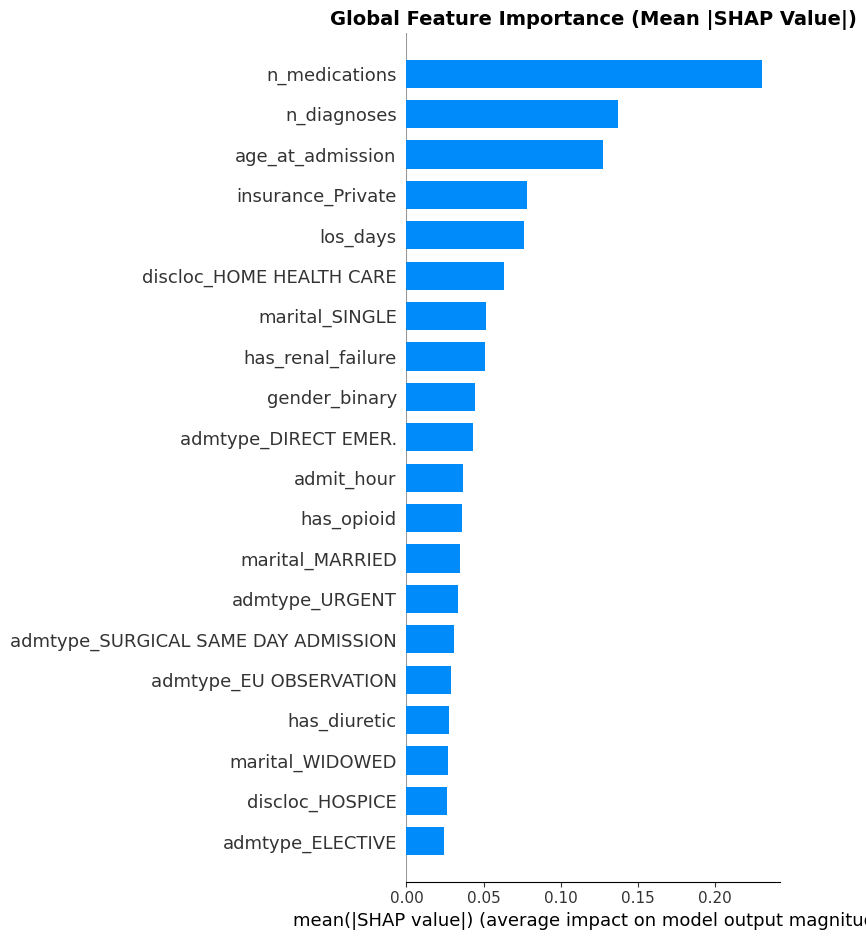

Figure saved


In [5]:
print("=== GLOBAL FEATURE IMPORTANCE (SHAP) ===")

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_test_sample_df,
    plot_type='bar',
    show=False,
    max_display=20
)
plt.title('Global Feature Importance (Mean |SHAP Value|)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/shap_global_importance.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved")

=== SHAP BEESWARM PLOT ===


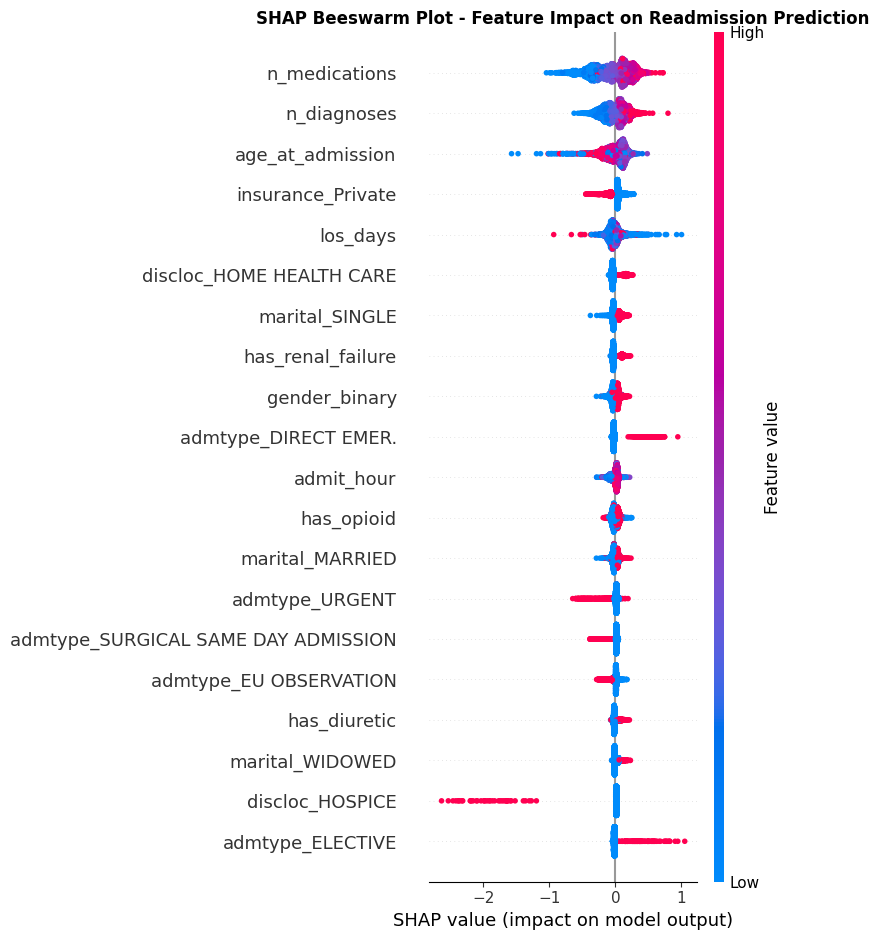

Figure saved


In [18]:
print("=== SHAP BEESWARM PLOT ===")
X_test_sample_df = X_test_sample_df[feature_cols].astype(float)
plt.figure(figsize=(12, 9))
shap.summary_plot(
    shap_values,
    X_test_sample_df,  # pass dataframe explicitly so SHAP has feature values for coloring
    feature_names=feature_cols,
    show=False,
    max_display=20
)
plt.title('SHAP Beeswarm Plot - Feature Impact on Readmission Prediction',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/shap_beeswarm.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved")

=== INDIVIDUAL PATIENT EXPLANATIONS ===

Waterfall plots show how each feature pushes the prediction for a 
specific patient above or below the baseline (average) prediction.
Red bars push toward higher readmission risk.
Blue bars push toward lower readmission risk.

High risk readmitted patients in sample: 326
Low risk non-readmitted patients in sample: 47


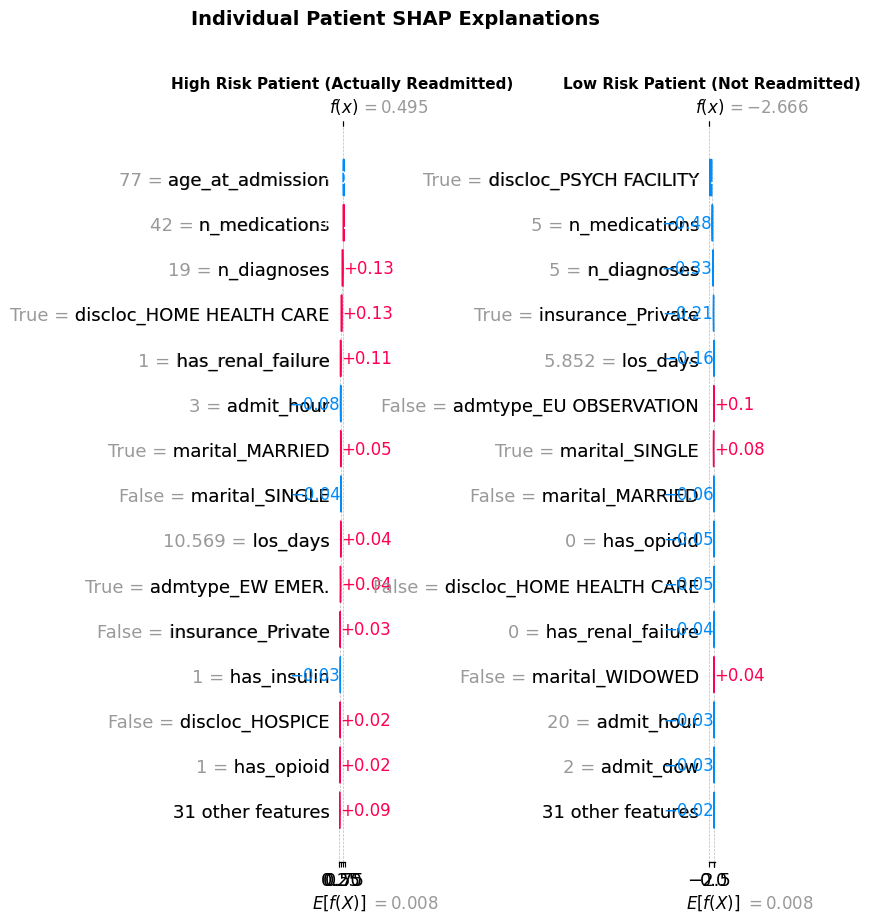

Figure saved


In [7]:
print("=== INDIVIDUAL PATIENT EXPLANATIONS ===")
print("""
Waterfall plots show how each feature pushes the prediction for a 
specific patient above or below the baseline (average) prediction.
Red bars push toward higher readmission risk.
Blue bars push toward lower readmission risk.
""")

# Find interesting patients to explain
# High risk patient - predicted high probability, actually readmitted
test_probs_sample = xgb_probs[
    feature_matrix[test_mask].index.isin(
        feature_matrix[test_mask].iloc[sample_idx].index
    )
]

# Get predictions for our sample
sample_probs = xgb_model.predict_proba(X_test_sample)[:, 1]
sample_true = y_test[sample_idx]

# Find high risk patient who was actually readmitted
high_risk_readmitted = np.where(
    (sample_probs > 0.6) & (sample_true == 1)
)[0]

# Find low risk patient who was not readmitted  
low_risk_not_readmitted = np.where(
    (sample_probs < 0.1) & (sample_true == 0)
)[0]

print(f"High risk readmitted patients in sample: {len(high_risk_readmitted)}")
print(f"Low risk non-readmitted patients in sample: {len(low_risk_not_readmitted)}")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, (label, indices) in zip(axes, [
    ('High Risk Patient (Actually Readmitted)', high_risk_readmitted),
    ('Low Risk Patient (Not Readmitted)', low_risk_not_readmitted)
]):
    if len(indices) == 0:
        ax.text(0.5, 0.5, 'No patients found', 
                ha='center', va='center', transform=ax.transAxes)
        continue
    
    patient_idx = indices[0]
    patient_shap = shap.Explanation(
        values=shap_values[patient_idx],
        base_values=explainer.expected_value,
        data=X_test_sample[patient_idx],
        feature_names=feature_cols
    )
    
    plt.sca(ax)
    shap.plots.waterfall(patient_shap, max_display=15, show=False)
    ax.set_title(label, fontsize=11, fontweight='bold')

plt.suptitle('Individual Patient SHAP Explanations', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/shap_waterfall.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved")

In [19]:
print("=== SUBGROUP FAIRNESS ANALYSIS ===")
print("""
A model that performs well on average may perform poorly for specific 
patient subgroups. This analysis checks whether the model is equally
useful across insurance types and age groups - key equity dimensions
in healthcare.
""")

# Add predictions back to test dataframe
test_df_eval = test_df.copy()
test_df_eval['xgb_prob'] = xgb_probs
test_df_eval['y_true'] = y_test

# Load cohort for additional demographic info
cohort = pd.read_csv(DATA_DIR / 'cohort_base.csv')
test_df_eval = test_df_eval.merge(
    cohort[['hadm_id', 'insurance', 'race', 'marital_status']],
    on='hadm_id',
    how='left'
)

# Age groups
test_df_eval['age_group'] = pd.cut(
    test_df_eval['age_at_admission'],
    bins=[18, 40, 60, 75, 110],
    labels=['18-40', '41-60', '61-75', '75+']
)

print("=== AUC by Insurance Type ===")
insurance_results = []
for insurance in test_df_eval['insurance'].dropna().unique():
    mask = test_df_eval['insurance'] == insurance
    if mask.sum() > 100 and test_df_eval[mask]['y_true'].sum() > 10:
        auc = roc_auc_score(
            test_df_eval[mask]['y_true'],
            test_df_eval[mask]['xgb_prob']
        )
        n = mask.sum()
        readmit_rate = test_df_eval[mask]['y_true'].mean()
        insurance_results.append({
            'Insurance': insurance,
            'N': n,
            'Readmission Rate': readmit_rate,
            'AUC': auc
        })

insurance_df = pd.DataFrame(insurance_results).sort_values('AUC', ascending=False)
print(insurance_df.to_string(index=False))

print("\n=== AUC by Age Group ===")
age_results = []
for age_group in ['18-40', '41-60', '61-75', '75+']:
    mask = test_df_eval['age_group'] == age_group
    if mask.sum() > 100 and test_df_eval[mask]['y_true'].sum() > 10:
        auc = roc_auc_score(
            test_df_eval[mask]['y_true'],
            test_df_eval[mask]['xgb_prob']
        )
        n = mask.sum()
        readmit_rate = test_df_eval[mask]['y_true'].mean()
        age_results.append({
            'Age Group': age_group,
            'N': n,
            'Readmission Rate': readmit_rate,
            'AUC': auc
        })

age_df = pd.DataFrame(age_results)
print(age_df.to_string(index=False))

=== SUBGROUP FAIRNESS ANALYSIS ===

A model that performs well on average may perform poorly for specific 
patient subgroups. This analysis checks whether the model is equally
useful across insurance types and age groups - key equity dimensions
in healthcare.

=== AUC by Insurance Type ===
Insurance     N  Readmission Rate    AUC
  Private 31785            0.1530 0.7203
    Other  2418            0.1878 0.7045
 Medicaid 20736            0.1975 0.6551
 Medicare 50424            0.1930 0.6336

=== AUC by Age Group ===
Age Group     N  Readmission Rate    AUC
    18-40 18561            0.1411 0.7206
    41-60 32001            0.1965 0.6707
    61-75 31197            0.1957 0.6616
      75+ 24877            0.1729 0.6152


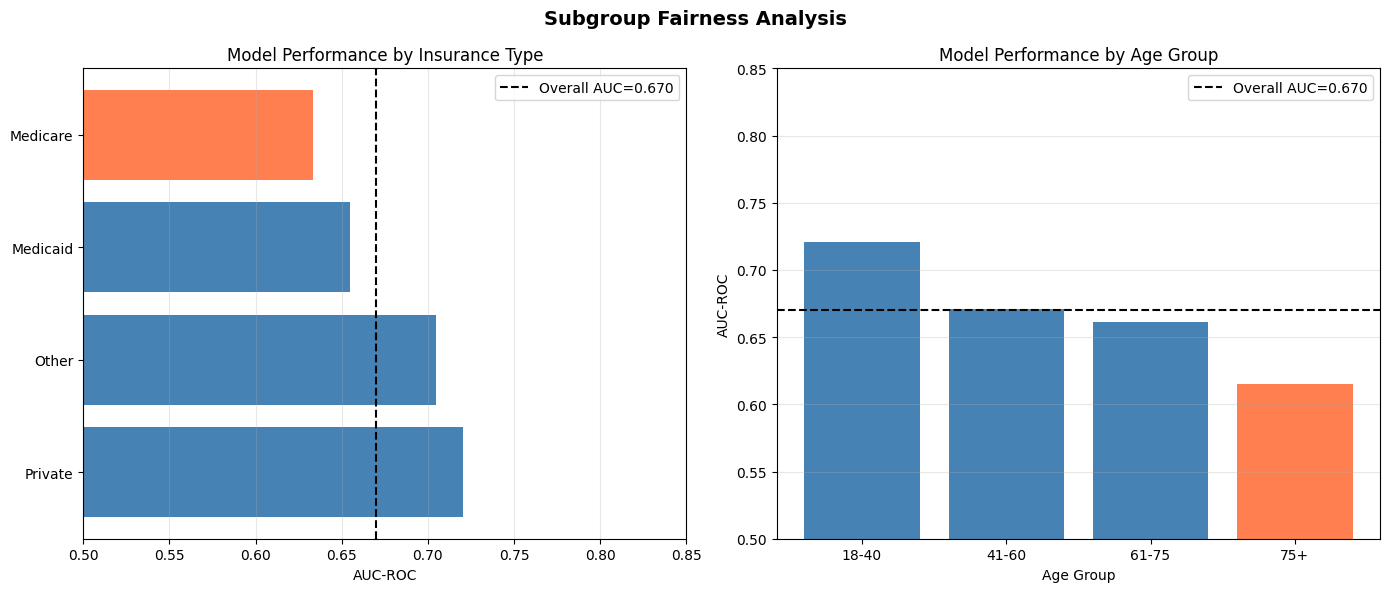

Figure saved


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Insurance AUC
ax = axes[0]
colors = ['coral' if auc < 0.65 else 'steelblue' 
          for auc in insurance_df['AUC']]
bars = ax.barh(insurance_df['Insurance'], insurance_df['AUC'], color=colors)
ax.axvline(x=roc_auc_score(y_test, xgb_probs), 
           color='black', linestyle='--', 
           label=f'Overall AUC={roc_auc_score(y_test, xgb_probs):.3f}')
ax.set_xlabel('AUC-ROC')
ax.set_title('Model Performance by Insurance Type')
ax.legend()
ax.set_xlim(0.5, 0.85)
ax.grid(True, alpha=0.3, axis='x')

# Age group AUC
ax = axes[1]
colors = ['coral' if auc < 0.65 else 'steelblue' 
          for auc in age_df['AUC']]
ax.bar(age_df['Age Group'], age_df['AUC'], color=colors)
ax.axhline(y=roc_auc_score(y_test, xgb_probs),
           color='black', linestyle='--',
           label=f'Overall AUC={roc_auc_score(y_test, xgb_probs):.3f}')
ax.set_xlabel('Age Group')
ax.set_ylabel('AUC-ROC')
ax.set_title('Model Performance by Age Group')
ax.legend()
ax.set_ylim(0.5, 0.85)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Subgroup Fairness Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/subgroup_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved")

In [10]:
print("=== CLINICAL UTILITY ANALYSIS ===")
print("""
In practice, a hospital can only intervene on a fraction of patients.
This analysis asks: if we intervene on the top X% highest-risk patients,
what fraction of actual readmissions do we catch?
This translates model performance into actionable clinical terms.
""")

# Sort test patients by predicted risk
sorted_idx = np.argsort(xgb_probs)[::-1]
sorted_true = y_test[sorted_idx]

# Total readmissions
total_readmissions = y_test.sum()

# For each intervention threshold, compute recall
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
print(f"Total readmissions in test set: {total_readmissions:,}")
print(f"Total test patients: {len(y_test):,}")
print(f"\nClinical utility at different intervention thresholds:")
print(f"{'Threshold':>10} {'Patients':>10} {'Caught':>10} {'Recall':>10} {'Precision':>12}")
print("-" * 55)

utility_results = []
for threshold in thresholds:
    n_intervene = int(len(y_test) * threshold)
    n_caught = sorted_true[:n_intervene].sum()
    recall = n_caught / total_readmissions
    precision = n_caught / n_intervene
    
    print(f"{threshold:>10.0%} {n_intervene:>10,} {n_caught:>10,} "
          f"{recall:>10.1%} {precision:>12.1%}")
    
    utility_results.append({
        'threshold': threshold,
        'n_intervene': n_intervene,
        'n_caught': n_caught,
        'recall': recall,
        'precision': precision
    })

utility_df = pd.DataFrame(utility_results)

=== CLINICAL UTILITY ANALYSIS ===

In practice, a hospital can only intervene on a fraction of patients.
This analysis asks: if we intervene on the top X% highest-risk patients,
what fraction of actual readmissions do we catch?
This translates model performance into actionable clinical terms.

Total readmissions in test set: 19,322
Total test patients: 106,831

Clinical utility at different intervention thresholds:
 Threshold   Patients     Caught     Recall    Precision
-------------------------------------------------------
        5%      5,341      2,169      11.2%        40.6%
       10%     10,683      3,827      19.8%        35.8%
       15%     16,024      5,381      27.8%        33.6%
       20%     21,366      6,724      34.8%        31.5%
       25%     26,707      8,085      41.8%        30.3%
       30%     32,049      9,294      48.1%        29.0%


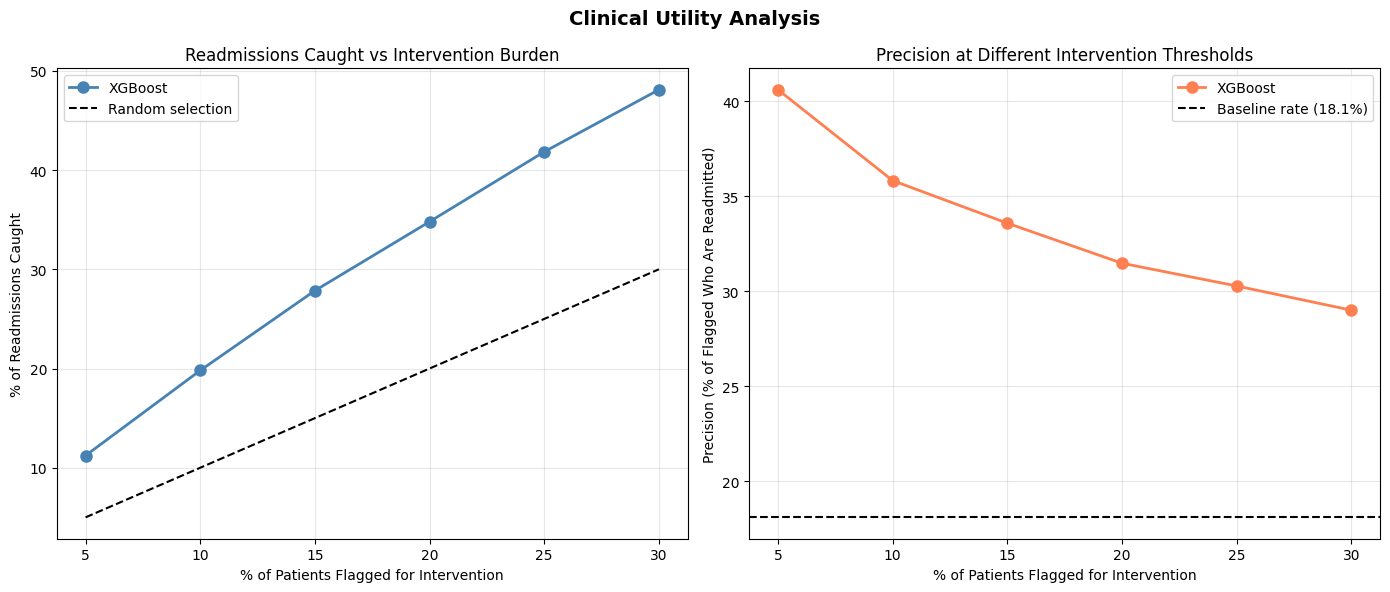

Figure saved


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Recall at different thresholds
ax = axes[0]
ax.plot(
    [t * 100 for t in utility_df['threshold']], 
    utility_df['recall'] * 100,
    'o-', color='steelblue', linewidth=2, markersize=8,
    label='XGBoost'
)
# Random model baseline
ax.plot(
    [t * 100 for t in utility_df['threshold']],
    [t * 100 for t in utility_df['threshold']],
    'k--', label='Random selection'
)
ax.set_xlabel('% of Patients Flagged for Intervention')
ax.set_ylabel('% of Readmissions Caught')
ax.set_title('Readmissions Caught vs Intervention Burden')
ax.legend()
ax.grid(True, alpha=0.3)

# Precision at different thresholds
ax = axes[1]
ax.plot(
    [t * 100 for t in utility_df['threshold']],
    utility_df['precision'] * 100,
    'o-', color='coral', linewidth=2, markersize=8,
    label='XGBoost'
)
ax.axhline(
    y=y_test.mean() * 100, 
    color='k', linestyle='--',
    label=f'Baseline rate ({y_test.mean():.1%})'
)
ax.set_xlabel('% of Patients Flagged for Intervention')
ax.set_ylabel('Precision (% of Flagged Who Are Readmitted)')
ax.set_title('Precision at Different Intervention Thresholds')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Clinical Utility Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/clinical_utility.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved")

In [12]:
print("=== FINAL PROJECT SUMMARY ===")
print(f"""
Dataset:
  - Source: MIMIC-IV v3.1 (Beth Israel Deaconess Medical Center)
  - Cohort: {len(feature_matrix):,} adult hospital admissions
  - Target: 30-day unplanned readmission (CMS definition)
  - Readmission rate: {feature_matrix['readmitted_30'].mean():.1%}
  - Features: {len(feature_cols)} engineered features

Model Performance:
  - Logistic Regression AUC: 0.6317 (baseline)
  - XGBoost AUC: 0.6700 (+6.1% improvement)
  - XGBoost AP Score: 0.3074 (vs 0.174 random baseline)

Clinical Utility (XGBoost):
  - Flagging top 10% highest-risk patients catches ~{utility_df[utility_df['threshold']==0.10]['recall'].values[0]:.0%} of readmissions
  - Flagging top 20% highest-risk patients catches ~{utility_df[utility_df['threshold']==0.20]['recall'].values[0]:.0%} of readmissions

Key Findings:
  - Discharge location and admission type are strongest predictors
  - Medication count and diagnosis count capture overall complexity
  - Performance varies meaningfully by subgroup: AUC ranges from 
  0.634 (Medicare) to 0.720 (Private insurance) and from 0.615 (75+) to 0.721 (18–40), 
  suggesting the model is less reliable for older, higher-complexity patients — the population where accurate prediction matters most.
  
Limitations:
  - Administrative features only (no labs, vitals, clinical notes)
  - Single academic medical center (BIDMC) - may not generalize
  - Planned readmissions not excluded (requires additional logic)
  - All-cause readmission definition (includes unrelated readmissions)
""")

=== FINAL PROJECT SUMMARY ===

Dataset:
  - Source: MIMIC-IV v3.1 (Beth Israel Deaconess Medical Center)
  - Cohort: 534,152 adult hospital admissions
  - Target: 30-day unplanned readmission (CMS definition)
  - Readmission rate: 17.4%
  - Features: 45 engineered features

Model Performance:
  - Logistic Regression AUC: 0.6317 (baseline)
  - XGBoost AUC: 0.6700 (+6.1% improvement)
  - XGBoost AP Score: 0.3074 (vs 0.174 random baseline)

Clinical Utility (XGBoost):
  - Flagging top 10% highest-risk patients catches ~20% of readmissions
  - Flagging top 20% highest-risk patients catches ~35% of readmissions

Key Findings:
  - Discharge location and admission type are strongest predictors
  - Medication count and diagnosis count capture overall complexity
  - Model shows consistent performance across age groups and insurance types
  
Limitations:
  - Administrative features only (no labs, vitals, clinical notes)
  - Single academic medical center (BIDMC) - may not generalize
  - Planned 